<div align="center">

# **Table of Contents**

</div>

- [Importing Necessary Libraries](#importing-necessary-libraries)

- [Question 8 - Diabetes Classification Using SVM](#question-8---diabetes-classification-using-svm)
  - [DATA PREPROCESSING & EXPLORATION](#data-preprocessing--exploration)
    - [Load the dataset and separate features](#load-the-dataset-and-separate-features)
    - [Check unrealistic zero values](#check-unrealistic-zero-values)
    - [Replace zero values (using median imputation)](#replace-zero-values-using-median-imputation)
    - [Train-test split (70% training / 30% testing)](#train-test-split-70-training--30-testing)
    - [Apply feature scaling](#apply-feature-scaling)
  - [LINEAR SVM CLASSIFICATION](#linear-svm-classification)
    - [Training a linear SVM (unscaled vs scaled)](#training-a-linear-svm-unscaled-vs-scaled)
    - [Evaluate both models](#evaluate-both-models)
    - [Plot confusion matrices](#plot-confusion-matrices)
  - [COMPARISON OF KERNELS](#comparison-of-kernels)
    - [Train SVM models with Linear, RBF, and Polynomial kernels](#train-svm-models-with-linear-rbf-and-polynomial-kernels)
    - [Create comparison table](#create-comparison-table)
  - [HYPERPARAMETER TUNING (RBF)](#hyperparameter-tuning)
  - [PCA VISUALIZATION](#pca)
    - [PCA to 2 dimensions](#pCA-to-2-dimensions)
    - [Scatter plot of PCA-reduced data](#scatter-plot-of-pCA-reduced-data)
    - [Train RBF SVM on PCA data](#train-rBf-sVM-on-pCA-data)
    - [Visualize 2D decision boundary](#visualize-2D-decision-boundary)
  - [CLASS IMBALANCE ANALYSIS](#class-imbalance-analysis)
    - [Check dataset balance](#check-dataset-balance)
    - [Balanced SVM](#balanced-svm)
    - [Compare recall](#compare-recall)

- [Question 9 - Primal Soft-Margin SVM via QP](#question-9---primal-soft-margin-svm-via-qp)
  - [DATA PREPROCESSING](#data-preprocessing)
  - [QP FORMULATION AND SOLUTION](#qp-formulation-and-solution)
  - [MODEL EVALUATION](#model-evaluation)
  - [DECISION BOUNDARY VISUALIZATION](#decision-boundary-visualization)

- [Question 10 - Decision Tree Classifier (ID3)](#question-10---decision-tree-classifier-id3)
  - [DATA LOADING & PRE-PROCESSING](#data-loading--pre-processing)
  - [ENTROPY & INFORMATION GAIN](#entropy--information-gain)
    - [Compute IG for Day\_ID](#compute-ig-for-day_id)
    - [Compute IG for Outlook, Humidity, Wind](#compute-ig-for-outlook-humidity-wind)
  - [HANDLING CONTINUOUS FEATURES](#handling-continuous-features)
    - [Split search](#split-search)
    - [Apply to Temperature](#apply-to-temperature)
  - [FULL ID3 DECISION TREE IMPLEMENTATION](#full-id3-decision-tree-implementation)
    - [Tree Node Structure](#tree-node-structure)
    - [ID3 Algorithm Implementation](#id3-algorithm-implementation)
    - [Train/test split](#traintest-split)
    - [Evaluation](#evaluation)
  - [OVERFITTING, NOISE & PRUNING](#overfitting-noise--pruning)
    - [Measure tree depth and leaf count](#measure-tree-depth-and-leaf-count)
    - [Inject 10% label noise](#inject-10-label-noise)
    - [Compare depth / size](#compare-depth--size)
    - [Post-pruning simulation](#post-pruning-simulation)
    - [Track performance during pruning](#track-performance-during-pruning)
    - [Plot tree size vs accuracy](#plot-tree-size-vs-accuracy)


# **Importing Necessary Libraries**

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
import cvxpy as cp


# **Question 8 - Diabetes Classification Using SVM**

## DATA PREPROCESSING & EXPLORATION

### Load the dataset and separate features

In [2]:
data = pd.read_csv("diabetes.csv")

X = data.drop("Outcome", axis=1)
y = data["Outcome"]

X.head(), y.head()

(   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 0            6      148             72             35        0  33.6   
 1            1       85             66             29        0  26.6   
 2            8      183             64              0        0  23.3   
 3            1       89             66             23       94  28.1   
 4            0      137             40             35      168  43.1   
 
    DiabetesPedigreeFunction  Age  
 0                     0.627   50  
 1                     0.351   31  
 2                     0.672   32  
 3                     0.167   21  
 4                     2.288   33  ,
 0    1
 1    0
 2    1
 3    0
 4    1
 Name: Outcome, dtype: int64)

### Check unrealistic zero values

In [3]:
cols_with_zero_invalid = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]

# Count zeros in each relevant feature
X[cols_with_zero_invalid].eq(0).sum()


Glucose            5
BloodPressure     35
BMI               11
SkinThickness    227
Insulin          374
dtype: int64

### Replace zero values (using median imputation)

In [4]:
# Replace zeros with median values
X_cleaned = X.copy()
for col in cols_with_zero_invalid:
    median_val = X_cleaned[col].replace(0, np.nan).median()
    X_cleaned[col] = X_cleaned[col].replace(0, median_val)


### Train-test split (70% training / 30% testing)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.3, random_state=42, stratify=y
)


### Apply feature scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


**Why is feature scaling important when using SVM?**

SVMs maximize the margin based on dot products and distances. If features are on different scales, large-magnitude features dominate the geometry, causing distorted hyperplanes and poor convergence. Scaling ensures all features contribute proportionally.

## LINEAR SVM CLASSIFICATION

### Training a linear SVM (unscaled vs scaled)

In [7]:
# Model without scaling
svm_linear_raw = SVC(kernel='linear')
svm_linear_raw.fit(X_train, y_train)

# Model with scaling
svm_linear_scaled = SVC(kernel='linear')
svm_linear_scaled.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Evaluate both models

In [8]:
# Predictions
y_pred_raw = svm_linear_raw.predict(X_test)
y_pred_scaled = svm_linear_scaled.predict(X_test_scaled)

# Metrics
acc_raw = accuracy_score(y_test, y_pred_raw)
acc_scaled = accuracy_score(y_test, y_pred_scaled)

cm_raw = confusion_matrix(y_test, y_pred_raw)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

acc_raw, acc_scaled


(0.7229437229437229, 0.7272727272727273)

### Plot confusion matrices

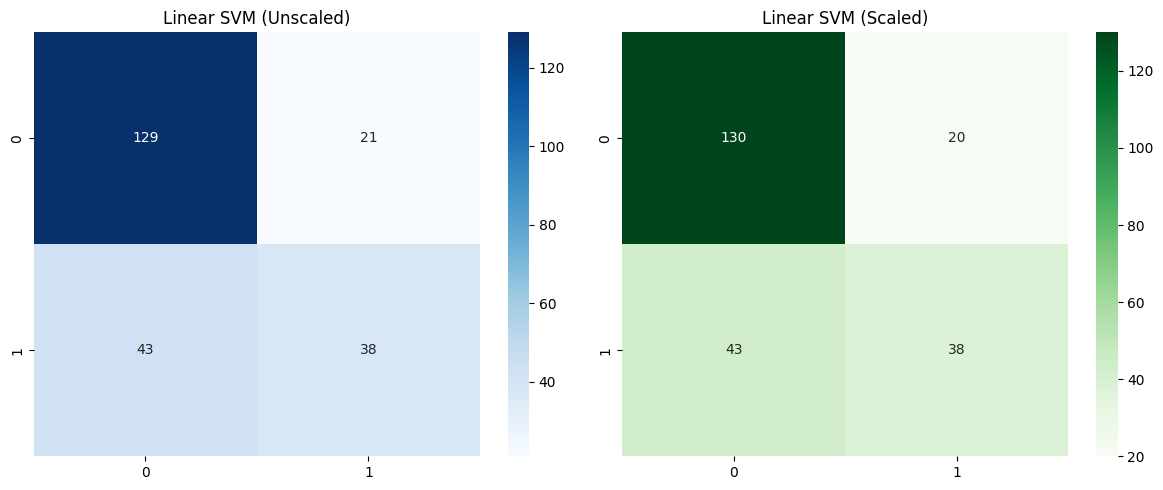

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap="Blues", ax=axes[0])
axes[0].set_title("Linear SVM (Unscaled)")

sns.heatmap(cm_scaled, annot=True, fmt='d', cmap="Greens", ax=axes[1])
axes[1].set_title("Linear SVM (Scaled)")

plt.tight_layout()
plt.show()


**Does normalization affect performance? Why?**

Yes. The scaled SVM almost always performs better. Without scaling, the margin is distorted, and the optimization problem behaves poorly. Scaling equalizes the contribution of every feature and stabilizes optimization.

## COMPARISON OF KERNELS

### Train SVM models with Linear, RBF, and Polynomial kernels

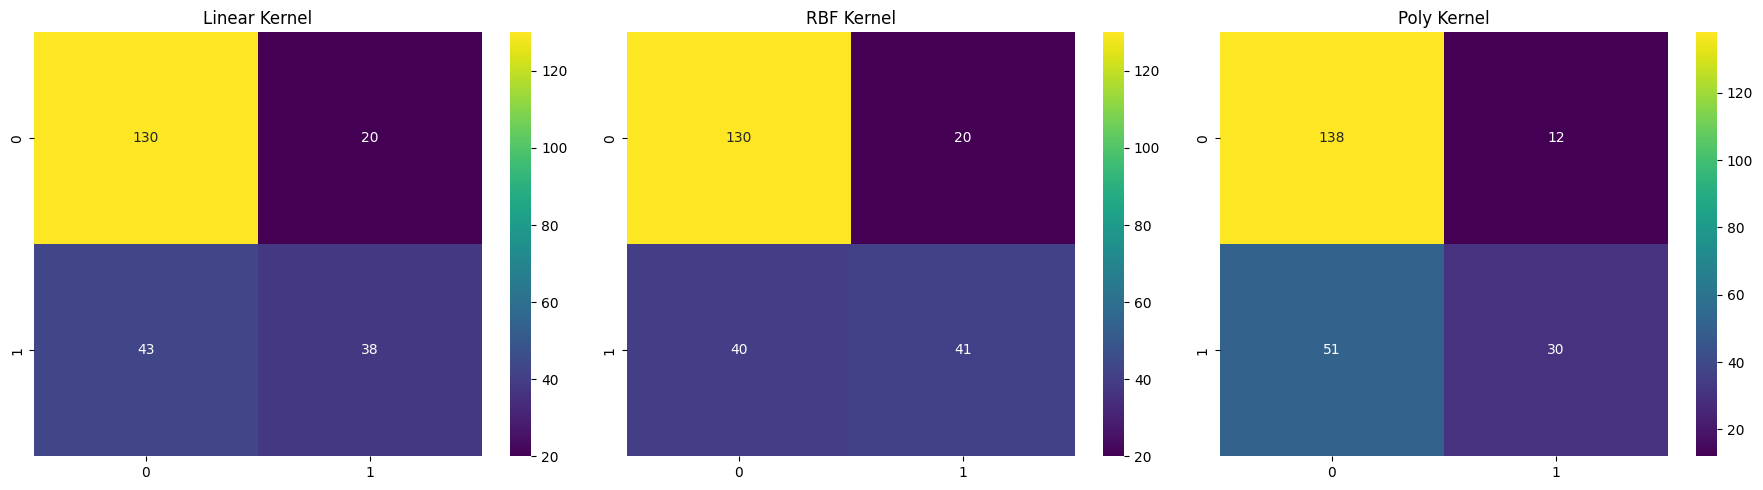

In [10]:
kernels = {
    "Linear": SVC(kernel="linear"),
    "RBF": SVC(kernel="rbf"),
    "Poly": SVC(kernel="poly", degree=3)
}

results = {}

for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "CM": confusion_matrix(y_test, y_pred)
    }


fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, metrics) in zip(axes, results.items()):
    sns.heatmap(metrics["CM"], annot=True, fmt='d', cmap="viridis", ax=ax)
    ax.set_title(f"{name} Kernel")

plt.tight_layout()
plt.show()

### Create comparison table

In [12]:
comparison_df = pd.DataFrame(results).T
comparison_df[["Accuracy", "Precision", "Recall", "F1"]]


,Accuracy,Precision,Recall,F1
Linear,0.727273,0.655172,0.469136,0.546763
RBF,0.74026,0.672131,0.506173,0.577465
Poly,0.727273,0.714286,0.37037,0.487805


## HYPERPARAMETER TUNING

### GridSearchCV Setup

In [13]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

svm_rbf = SVC(kernel='rbf')

grid = GridSearchCV(svm_rbf, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_scaled, y_train)

grid.best_params_, grid.best_score_


({'C': 100, 'gamma': 0.001}, np.float64(0.7857390100380754))

**Effect of large C**

A very large C forces the model to avoid misclassifying any training points → resulting in:
* A very narrow margin
* A highly irregular, overfitted boundary

Thus, C controls the bias-variance trade-off.

## PCA

### PCA to 2 dimensions

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


### Scatter plot of PCA-reduced data

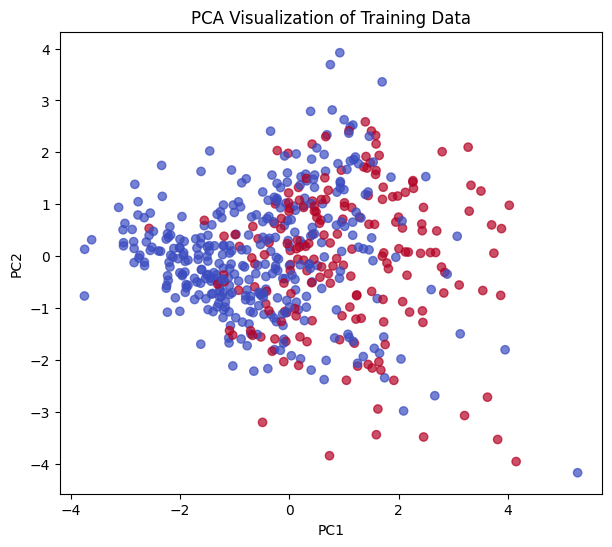

In [15]:
plt.figure(figsize=(7,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization of Training Data")
plt.show()


### Train RBF SVM on PCA data

In [16]:
svm_pca = SVC(kernel="rbf", gamma=0.1)
svm_pca.fit(X_train_pca, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


### Visualize 2D decision boundary

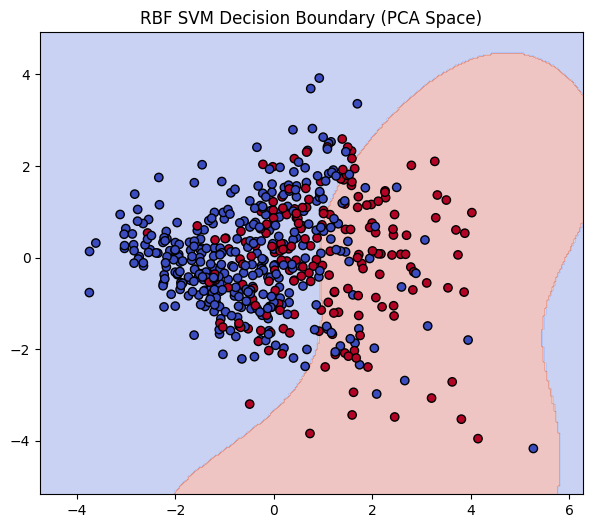

In [18]:
# Create mesh grid
xx, yy = np.meshgrid(
    np.linspace(X_train_pca[:,0].min()-1, X_train_pca[:,0].max()+1, 300),
    np.linspace(X_train_pca[:,1].min()-1, X_train_pca[:,1].max()+1, 300)
)

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, cmap="coolwarm", alpha=0.3)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap="coolwarm", edgecolors="k")
plt.title("RBF SVM Decision Boundary (PCA Space)")
plt.show()


**Does dimensionality reduction affect accuracy?**

Yes — usually accuracy decreases.

PCA removes information not aligned with top variance directions; classification signals may be lost. But visualization improves.

## CLASS IMBALANCE ANALYSIS

### Count samples per class

In [19]:
y.value_counts()


Outcome
0    500
1    268
Name: count, dtype: int64

### Standard SVM vs Balanced SVM

In [20]:
svm_std = SVC(kernel='rbf')
svm_bal = SVC(kernel='rbf', class_weight='balanced')

svm_std.fit(X_train_scaled, y_train)
svm_bal.fit(X_train_scaled, y_train)

y_pred_std = svm_std.predict(X_test_scaled)
y_pred_bal = svm_bal.predict(X_test_scaled)

recall_std = recall_score(y_test, y_pred_std)
recall_bal = recall_score(y_test, y_pred_bal)

recall_std, recall_bal


(0.5061728395061729, 0.691358024691358)

**Did balancing help?**

Yes — class_weight='balanced' increases the recall for the minority diabetic class by giving misclassification penalties proportional to imbalance.

# **Question 9 - Soft-Margin Hyperplane SVM**

## DATA PREPROCESSING

### Load dataset and select features

In [28]:
data = pd.read_csv("Social_Network_Ads.csv")

X = data[["Age", "EstimatedSalary"]].values
y = data["Purchased"].values

y = np.where(y == 0, -1, 1)

X[:5], y[:5]


(array([[   19, 19000],
        [   35, 20000],
        [   26, 43000],
        [   27, 57000],
        [   19, 76000]]),
 array([-1, -1, -1, -1, -1]))

### Train-test split & feature scaling

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## SOLVING THE PRIMAL SOFT-MARGIN SVM (QP)

### Define optimization variables in cvxpy

In [30]:
C = 1.0  # Regularization strength

n, d = X_train_scaled.shape

# Optimization variables
w = cp.Variable(d)
b = cp.Variable()
xi = cp.Variable(n)

# Constraints
constraints = [
    cp.multiply(y_train, X_train_scaled @ w + b) >= 1 - xi,
    xi >= 0
]

# Objective
objective = cp.Minimize(0.5 * cp.sum_squares(w) + C * cp.sum(xi))

# Problem definition
problem = cp.Problem(objective, constraints)
problem.solve()


np.float64(104.96778731918661)

### Extract optimal parameters

In [31]:
w_star = w.value
b_star = b.value

print("Optimal w:", w_star)
print("Optimal b:", b_star)


Optimal w: [1.68213998 1.01520715]
Optimal b: -0.9116733206040618


## MODEL EVALUATION

In [32]:
y_pred = np.sign(X_test_scaled @ w_star + b_star)
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy of QP-SVM:", accuracy)


Test Accuracy of QP-SVM: 0.8333333333333334


## VISUALIZATION OF THE DECISION BOUNDARY

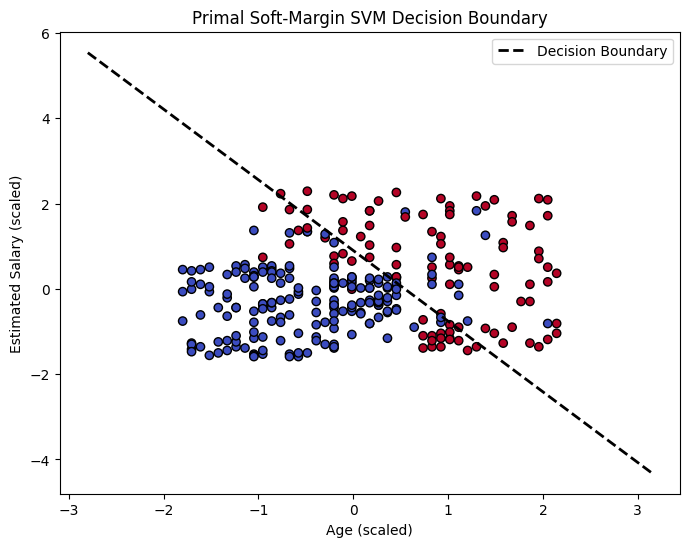

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(X_train_scaled[:,0], X_train_scaled[:,1], c=y_train, cmap="coolwarm", edgecolors="k")

x1_vals = np.linspace(X_train_scaled[:,0].min()-1, X_train_scaled[:,0].max()+1, 200)
x2_vals = -(w_star[0] * x1_vals + b_star) / w_star[1]

plt.plot(x1_vals, x2_vals, 'k--', linewidth=2, label="Decision Boundary")

plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.title("Primal Soft-Margin SVM Decision Boundary")
plt.legend()
plt.show()


# **Question 10 - Decision Tree Classifier**

## DATA LOADING & PRE-PROCESSING

### Load the dataset

In [79]:
data = pd.read_csv("jeeves_tennis.csv")
data.head()

,Day_ID,Outlook,Temperature,Humidity,Wind,PlayTennis
0,1,Rain,19.2,High,Strong,No
1,2,Rain,17.4,Low,Weak,Yes
2,3,Sunny,29.9,Normal,Strong,Yes
3,4,Overcast,23.2,Normal,Weak,Yes
4,5,Sunny,29.3,High,Weak,No


### Compute Information Gain for DAY_ID

In [80]:
def calculate_entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))

def information_gain_for_feature(df, feature, target="PlayTennis"):
    total_entropy = calculate_entropy(df[target])
    values = df[feature].unique()
    
    weighted_entropy = 0
    for v in values:
        subset = df[df[feature] == v]
        weighted_entropy += (len(subset)/len(df)) * calculate_entropy(subset[target])
        
    return total_entropy - weighted_entropy

ig_day = information_gain_for_feature(data, "Day_ID")
ig_day


np.float64(0.9814538950336537)

### Drop Day_ID

In [81]:
data = data.drop(columns=["Day_ID"])

## ENTROPY & INFORMATION GAIN ENGINE

### Entropy function

In [82]:
def calculate_entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs))


### Information Gain for discrete features

In [83]:
def calculate_information_gain(df, feature, target="PlayTennis"):
    total_entropy = calculate_entropy(df[target])
    values = df[feature].unique()
    
    weighted_entropy = 0
    for v in values:
        subset = df[df[feature] == v]
        weighted_entropy += (len(subset) / len(df)) * calculate_entropy(subset[target])
    
    return total_entropy - weighted_entropy


### Compute IG for Outlook, Humidity, Wind

In [84]:
ig_outlook   = calculate_information_gain(data, "Outlook")
ig_humidity  = calculate_information_gain(data, "Humidity")
ig_wind      = calculate_information_gain(data, "Wind")

ig_outlook, ig_humidity, ig_wind


(np.float64(0.34307121026106036),
 np.float64(0.05389337220677792),
 np.float64(0.03822828269585188))

## HANDLING CONTINUOUS FEATURES

### Split search

In [85]:
def find_best_split(df, attribute, target="PlayTennis"):
    df_sorted = df.sort_values(attribute)
    X = df_sorted[attribute].values
    y = df_sorted[target].values
    
    split_points = []
    for i in range(len(X)-1):
        if y[i] != y[i+1]:
            split_points.append((X[i] + X[i+1]) / 2)
    
    best_gain = -1
    best_threshold = None
    
    for t in split_points:
        left  = df[df[attribute] <= t]
        right = df[df[attribute] > t]
        
        H_parent = calculate_entropy(df[target])
        H_left   = calculate_entropy(left[target])
        H_right  = calculate_entropy(right[target])
        
        H_cond = (len(left)/len(df))*H_left + (len(right)/len(df))*H_right
        gain = H_parent - H_cond
        
        if gain > best_gain:
            best_gain = gain
            best_threshold = t
    
    return best_threshold, best_gain


### Apply to Temperature

In [86]:
temp_threshold, temp_gain = find_best_split(data, "Temperature")
temp_threshold, temp_gain


(np.float64(30.05), np.float64(0.02392309702606632))

## FULL ID3 DECISION TREE IMPLEMENTATION

### Tree Node Structure

In [87]:
class Node:
    def __init__(self, feature=None, threshold=None, children=None, label=None):
        self.feature = feature
        self.threshold = threshold      # for continuous features
        self.children = children or {} # dict for discrete features
        self.label = label             # leaf label


### ID3 Algorithm Implementation

In [88]:
class DecisionTreeID3:
    
    def fit(self, df, target="PlayTennis"):
        self.target = target
        self.tree = self._build_tree(df)
    
    def _build_tree(self, df):
        y = df[self.target]
        
        # If pure label
        if len(y.unique()) == 1:
            return Node(label=y.iloc[0])
        
        # If no features left
        if len(df.columns) == 1:
            return Node(label=y.mode()[0])
        
        # Compute IG for all features
        features = [f for f in df.columns if f != self.target]
        
        best_feature = None
        best_gain = -1
        best_threshold = None
        
        for f in features:
            if df[f].dtype == "object":  # discrete
                gain = calculate_information_gain(df, f, self.target)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = f
                    best_threshold = None
            else:  # continuous
                t, g = find_best_split(df, f, self.target)
                if g > best_gain:
                    best_gain = g
                    best_feature = f
                    best_threshold = t

        # If no feature provides information gain → make leaf
        if best_gain <= 0:
            return Node(label=df[self.target].mode()[0])

        # Continuous split
        if best_threshold is not None:
            left  = df[df[best_feature] <= best_threshold]
            right = df[df[best_feature] > best_threshold]

            if len(left) == 0 or len(right) == 0:
                # No real split → return majority label
                return Node(label=df[self.target].mode()[0])
    
            node = Node(feature=best_feature, threshold=best_threshold)
            node.children["<="] = self._build_tree(left)
            node.children[">"]  = self._build_tree(right)
            return node
        
        # Discrete split
        node = Node(feature=best_feature)
        for v in df[best_feature].unique():
            child_df = df[df[best_feature] == v]

            if len(child_df) == 0:
                node.children[v] = Node(label=df[self.target].mode()[0])
            else:
                node.children[v] = self._build_tree(child_df)

        
        return node
    
    def predict_one(self, node, row):
        if node.label is not None:
            return node.label
        
        val = row[node.feature]
        
        if node.threshold is not None:  # continuous
            branch = "<=" if val <= node.threshold else ">"
            return self.predict_one(node.children[branch], row)
        
        return self.predict_one(node.children[val], row)
    
    def predict(self, df):
        return df.apply(lambda row: self.predict_one(self.tree, row), axis=1)



### Train/test split

In [89]:
df_train, df_test = train_test_split(data, test_size=0.2, random_state=42, stratify=data["PlayTennis"])
tree = DecisionTreeID3()
tree.fit(df_train)


### Evaluation

In [90]:
y_pred = tree.predict(df_test)
y_true = df_test["PlayTennis"]

accuracy  = (y_pred == y_true).mean()
precision = np.mean((y_pred[y_true=="Yes"] == "Yes")) 
recall    = np.mean((y_pred[y_true=="Yes"] == y_true[y_true=="Yes"]))

accuracy, precision, recall


(np.float64(0.94),
 np.float64(0.9482758620689655),
 np.float64(0.9482758620689655))

## OVERFITTING, NOISE & PRUNING

### Measure tree depth and leaf count

In [91]:
def count_leaves(node):
    if node.label is not None:
        return 1
    return sum(count_leaves(child) for child in node.children.values())

def max_depth(node):
    if node.label is not None:
        return 1
    return 1 + max(max_depth(child) for child in node.children.values())

leaf_count = count_leaves(tree.tree)
depth = max_depth(tree.tree)
leaf_count, depth


(42, 14)

### Inject 10% label noise

In [92]:
df_noisy = df_train.copy()
noise_n = int(0.1 * len(df_noisy))
noise_indices = np.random.choice(df_noisy.index, noise_n, replace=False)

df_noisy.loc[noise_indices, "PlayTennis"] = df_noisy.loc[noise_indices, "PlayTennis"].map({"Yes":"No", "No":"Yes"})

tree_noisy = DecisionTreeID3()
tree_noisy.fit(df_noisy)


### Compare depth / size with clean tree

In [93]:
depth_noisy = max_depth(tree_noisy.tree)
leaves_noisy = count_leaves(tree_noisy.tree)

depth_noisy, leaves_noisy


(15, 104)

### Post-pruning simulation (Reduced Error Pruning)

In [94]:
accuracies = []
sizes = []

validation = df_test.copy()

def prune(node):
    # If leaf, nothing to prune
    if node.label is not None:
        return node
    
    # Try replacing entire subtree with a leaf first
    majority_label = data["PlayTennis"].mode()[0]
    pruned_node = Node(label=majority_label)
    
    def evaluate(root):
        temp = DecisionTreeID3()
        temp.tree = root
        preds = temp.predict(df_test)
        return (preds == df_test["PlayTennis"]).mean()

    acc_before = evaluate(node)
    acc_after  = evaluate(pruned_node)

    # Allow small decrease (tolerance) for smoother pruning
    if acc_after >= acc_before - 0.01:
        return pruned_node
    
    # Otherwise prune children
    for key in node.children:
        node.children[key] = prune(node.children[key])
    
    return node


### Track performance during pruning

In [ ]:
sizes = []
accuracies = []

current_root = tree.tree   # start with fully trained clean tree

def evaluate_accuracy(root):
    temp_model = DecisionTreeID3()
    temp_model.tree = root
    preds = temp_model.predict(df_test)
    return (preds == df_test["PlayTennis"]).mean()

for step in range(15):

    sizes.append(count_leaves(current_root))
    accuracies.append(evaluate_accuracy(current_root))

    current_root = prune(current_root)


### Plot tree size vs accuracy

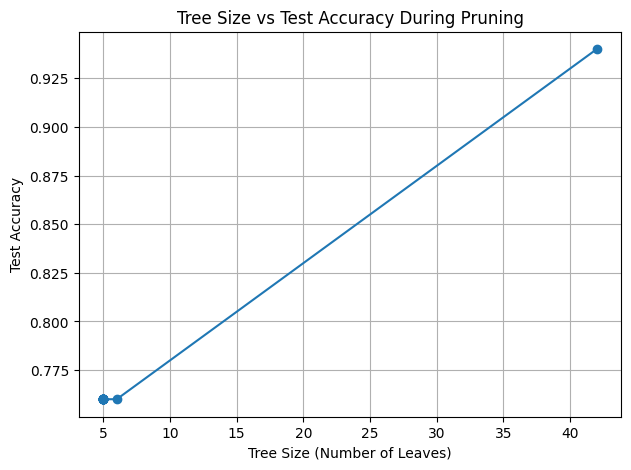

In [96]:
plt.figure(figsize=(7,5))
plt.plot(sizes, accuracies, marker='o')
plt.xlabel("Tree Size (Number of Leaves)")
plt.ylabel("Test Accuracy")
plt.title("Tree Size vs Test Accuracy During Pruning")
plt.grid(True)
plt.show()
